#### Parallelization

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
# test llm call
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage

llm = ChatGroq(model="qwen/qwen3-32b")
response = llm.invoke([HumanMessage(content=f"Hello")])
response.content

'<think>\nOkay, the user said "Hello". I should respond in a friendly and welcoming way. Maybe start with a greeting and offer help. Let me make sure the tone is approachable. I can ask how I can assist them today. Keep it simple and open-ended. Alright, that should work.\n</think>\n\nHello! How can I assist you today? 😊'

In [7]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# crate graph schema
class State(TypedDict):
    topic: str
    characters: str
    settings: str
    premises: str
    story_intro: str


#  crate nodes
def generate_characters(state: State):
    """Generate character descriptions"""
    msg=llm.invoke(f"create two character names and brief traits for a story about {state["topic"]}")
    return {"characters": msg.content}

def generate_settings(state: State):
    """Generate a story setting"""
    msg=llm.invoke(f"Describe a vivid setting for a story about {state["topic"]}")
    return {"settings": msg.content}

def generate_premise(state: State):
    """Generate a story premise"""
    msg=llm.invoke(f"write a one sentence plot for a story about {state["topic"]}")
    return {"premises": msg.content}

def combine_elements(state: State):
    """Combine the charactes, settings, premise into an intor"""
    msg=llm.invoke(
        f"write a short story introduction using these elements:\n"
        f"Characters: {state["characters"]}\n"
        f"Settings: {state["settings"]}\n"
        f"Premise: {state["premises"]}"
    )
    return {"story_intro": msg.content}

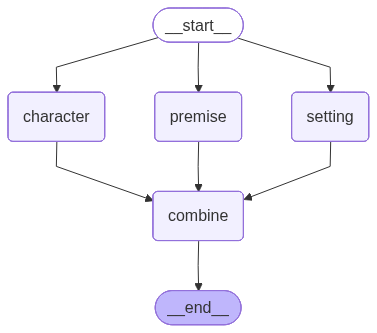

In [8]:
## build the graph
graph = StateGraph(State)

# create nodes
graph.add_node("character", generate_characters)
graph.add_node("setting", generate_settings)
graph.add_node("premise", generate_premise)
graph.add_node("combine", combine_elements)

# add edges
graph.add_edge(START, "character")
graph.add_edge(START, "setting")
graph.add_edge(START, "premise")
graph.add_edge("character", "combine")
graph.add_edge("setting", "combine")
graph.add_edge("premise", "combine")
graph.add_edge("combine", END)

# compile the graph
builder = graph.compile()

# visualise the graph
display(Image(builder.get_graph().draw_mermaid_png()))

In [9]:
# invoke the graph
state={"topic": "time travel"}
result=builder.invoke(state)
result

{'topic': 'time travel',
 'characters': '<think>\nOkay, the user wants me to create two character names with brief traits for a time-travel story. Let\'s start by thinking about what makes time-travel stories compelling. Usually, there\'s a mix of science and personal stakes. Maybe one character is the scientist type, driven by logic, while the other is more emotional or has a personal reason to time travel.\n\nFirst character: Maybe a physicist. Names that sound academic but not too cliché. Maybe Dr. Elara Voss? Elara has a celestial ring, which fits time travel. She could be brilliant but maybe a bit reckless, focused on the science. Her motivation could be to fix past mistakes, which adds depth.\n\nSecond character: Needs to contrast Elara. Perhaps someone with a personal loss, like her sister disappearing. A name that feels more grounded, maybe Kael Morgan. Kael sounds strong, and "Morgan" is versatile. He could be a rogue adventurer, less concerned with rules, more with getting an

In [10]:
print(result["story_intro"])

<think>
Okay, I need to create a short story introduction using the given elements. Let me start by recalling the characters and the setting provided. The main characters are Dr. Elara Voss and Kael Morgan. Elara is a quantum physicist haunted by a past failure, while Kael is a scavenger from a collapsed future society, searching for his sister. The setting is the city of Tempus, a place where time is fluid and unstable, with architectural elements from different eras. The premise involves a time-travel plot with a paradox where the protagonist's actions cause the very disaster they're trying to prevent.

First, I should establish both characters in the setting. Maybe start with Elara in the Temporal Spire, working on her machine. Then introduce Kael as someone who enters her domain seeking help. Their interactions should highlight their conflicting motivations—Elara's scientific drive versus Kael's personal quest. The setting details should be vivid but not overwhelming, giving a sens